In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.metrics import mean_squared_error
from tensorflow.keras import layers, models, optimizers, utils, datasets
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import seaborn as sns


In [2]:
# Load Dataset from CSV file into pandas dataframe

file_path = "C:\\Users\\rohit\\Downloads\\Battery_RUL\\Battery_RUL.csv"

#"C:\\Users\\rohit\\Downloads\\Battery_RUL.csv"

RUL_Dataset = pd.read_csv(file_path)
#split data into train and test
train, test = train_test_split(RUL_Dataset, test_size=0.1, random_state=42)


In [3]:
RUL_Dataset.columns

Index(['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)',
       'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)',
       'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)',
       'RUL'],
      dtype='object')

In [4]:
rul = RUL_Dataset['RUL']
discharge_Time = RUL_Dataset['Discharge Time (s)']
cycle_index = RUL_Dataset['Cycle_Index']
max_voltage_discharge = RUL_Dataset['Max. Voltage Dischar. (V)']
min_voltage_discharge = RUL_Dataset['Min. Voltage Charg. (V)']
time = RUL_Dataset['Time at 4.15V (s)']

Text(0.5, 1.0, 'RUL vs Discharge Time (s)')

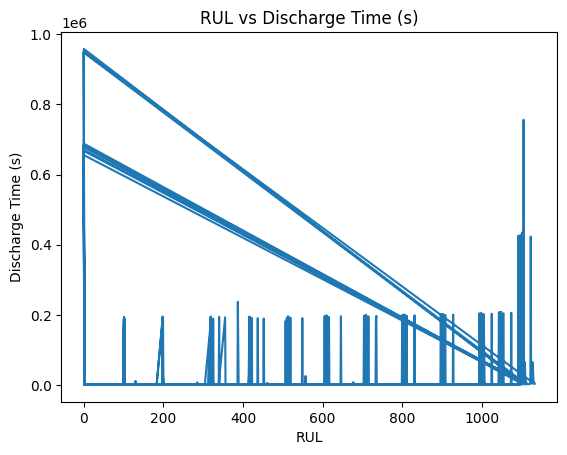

In [10]:
plt.plot(rul,discharge_Time)
plt.xlabel('RUL')
plt.ylabel('Discharge Time (s)')
plt.title('RUL vs Discharge Time (s)')

Text(0.5, 1.0, 'RUL vs Cycle_Index')

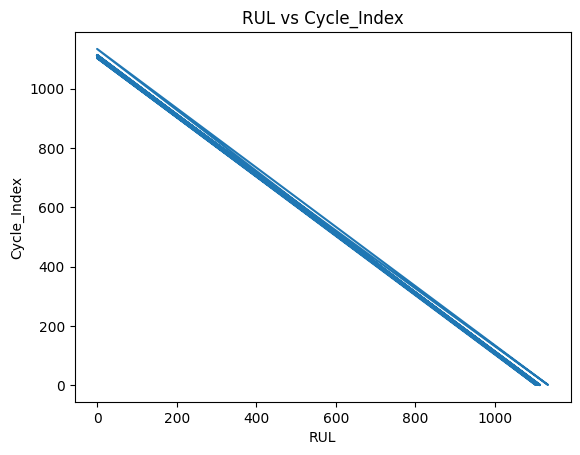

In [11]:
plt.plot(rul, cycle_index)
plt.xlabel('RUL')
plt.ylabel('Cycle_Index')
plt.title('RUL vs Cycle_Index')

Text(0.5, 1.0, 'RUL vs Min. Voltage Charg. (V)')

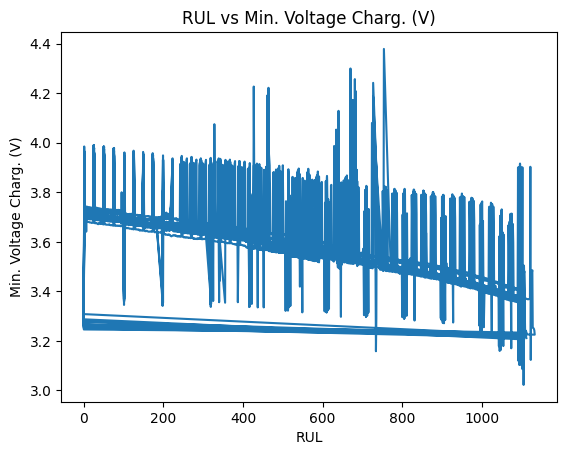

In [12]:
plt.plot(rul, min_voltage_discharge)
plt.xlabel('RUL')
plt.ylabel('Min. Voltage Charg. (V)')
plt.title('RUL vs Min. Voltage Charg. (V)')

Text(0.5, 1.0, 'RUL vs  Max. Voltage Dischar. (V)')

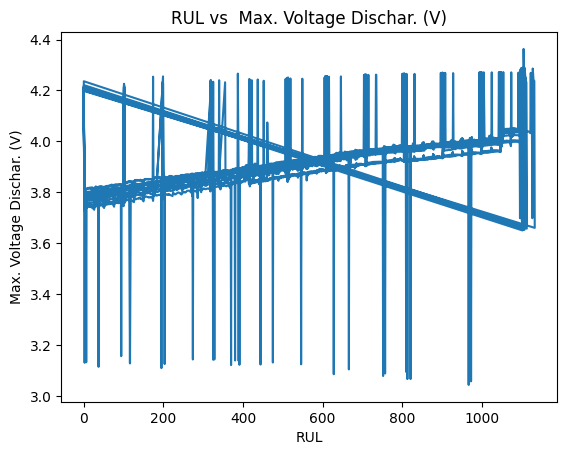

In [13]:
plt.plot(rul, max_voltage_discharge)
plt.xlabel('RUL')
plt.ylabel( 'Max. Voltage Dischar. (V)')
plt.title('RUL vs  Max. Voltage Dischar. (V)')

Text(0.5, 1.0, 'RUL vs  Time at 4.15V (s)')

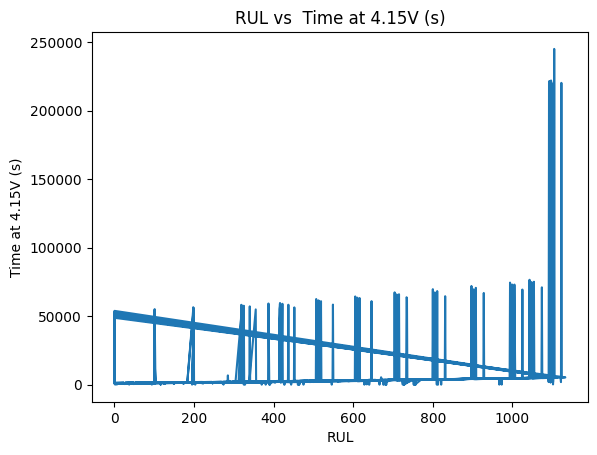

In [14]:
plt.plot(rul,time)
plt.xlabel('RUL')
plt.ylabel( 'Time at 4.15V (s)')
plt.title('RUL vs  Time at 4.15V (s)')

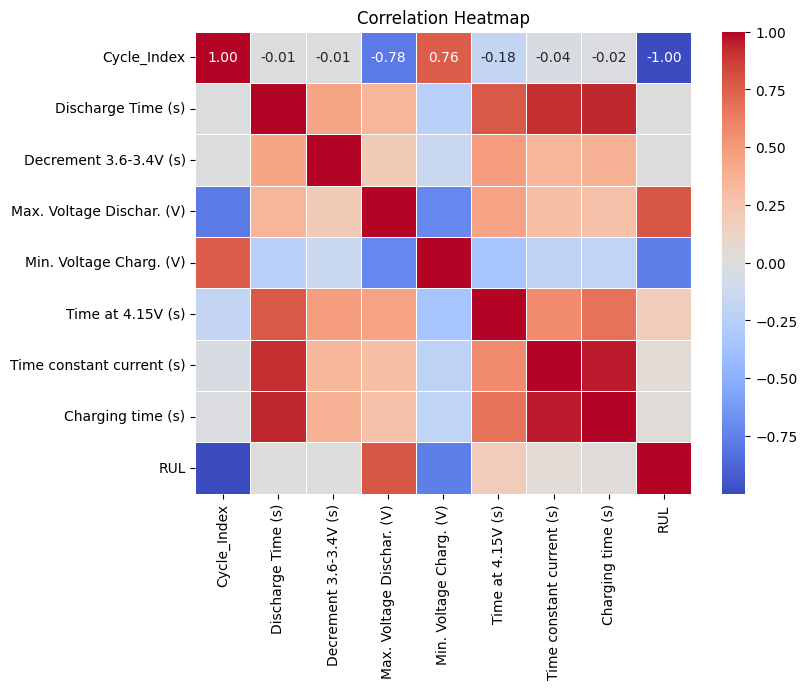

In [12]:
correlation_matrix = RUL_Dataset.corr()

# Create the heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True)

# Add titles and labels
plt.title("Correlation Heatmap")
plt.show()


In [3]:
# Sepreating out feeatures and labels training set
RUL_Dataset_features = train.copy()
RUL_Dataset_label = RUL_Dataset_features.pop("RUL")

In [4]:
# Sepreating out feeatures and labels test set
RUL_Dataset_features_test = test.copy()
RUL_Dataset_label_test = RUL_Dataset_features_test.pop("RUL")

In [5]:
#Convert feature to numpy array train
RUL_Dataset_features_array = np.array(RUL_Dataset_features)

In [6]:
#Convert feature to numpy array test
RUL_Dataset_features_array_test = np.array(RUL_Dataset_features_test)

## Deep Neural Network Model

In [7]:
# Create Deeplearning model in tensorflow with Normalization
normalization_layer = layers.Normalization()
normalization_layer.adapt(RUL_Dataset_features_array)
RUL_model = tf.keras.Sequential([
  normalization_layer,
  layers.Dense(32, activation='relu'),
  layers.Dense(1,activation = 'relu')
])
#Compile the mode with MSE loss and adam optimizer
RUL_model.compile(loss = tf.keras.losses.MeanSquaredError(),
                      optimizer = tf.keras.optimizers.Adam())

In [8]:
# fit the model
history = RUL_model.fit(RUL_Dataset_features_array, RUL_Dataset_label, epochs=200)

Epoch 1/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 409428.2812
Epoch 2/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 375986.3750
Epoch 3/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 299773.8438
Epoch 4/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 211655.3594
Epoch 5/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 124319.7656
Epoch 6/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 66151.3438
Epoch 7/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 35648.0039
Epoch 8/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23347.8184
Epoch 9/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16929.7617
Epoch 10/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13303.7275
Epoch 11/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9499.0264
Epoch 12/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7414.4458
Epoch 13/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5268.7925
Epoch 14/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [9]:
RUL_model.save("rul_model_v2.0.keras")

In [10]:
rul_model_reload = models.load_model('rul_model_v2.0.keras')

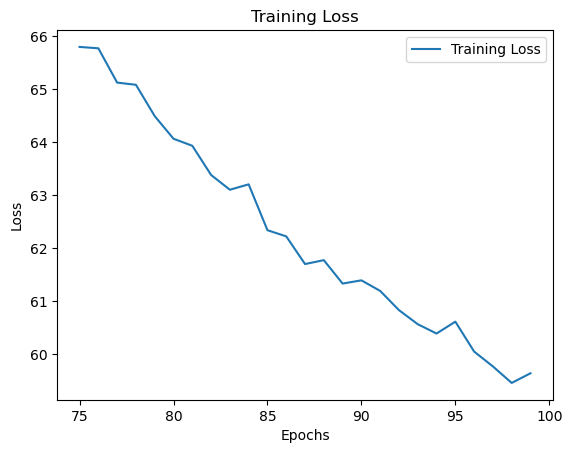

In [11]:
plt.plot(range(len(history.history['loss']))[75:100],history.history['loss'][75:100],label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [12]:
# MSE on test set
prediction = RUL_model.predict(RUL_Dataset_features_array_test)

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [13]:
RUL_model.evaluate(RUL_Dataset_features_array_test,RUL_Dataset_label_test)

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 49.9914


53.292301177978516

In [14]:
rul_model_reload.evaluate(RUL_Dataset_features_array_test,RUL_Dataset_label_test)

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 49.9914


53.292301177978516

In [15]:
mse = mean_squared_error(RUL_Dataset_label_test, prediction)

In [16]:
mse

53.29230855378371

Let's review model weights

In [17]:
model_weight = rul_model_reload.get_weights()

In [19]:
rul_model_reload.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 982 (3.84 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 17 (72.00 B)

 Optimizer params: 644 (2.52 KB)

In [23]:
model_weight

[array([5.5561835e+02, 4.5188735e+03, 1.2714200e+03, 3.9081354e+00,
        3.5773177e+00, 3.7552432e+03, 5.4306357e+03, 1.0022015e+04],
       dtype=float32),
 array([1.04248492e+05, 1.05243923e+09, 2.29842144e+08, 8.28758720e-03,
        1.51479989e-02, 8.12217440e+07, 6.00724544e+08, 6.61904832e+08],
       dtype=float32),
 0,
 array([[-5.722096  , -2.7799666 , -5.7359447 , -1.5327247 , -4.871603  ,
         -2.7132149 , -2.634653  , -2.5135787 , -2.1942635 , -2.4631426 ,
         -2.946417  ,  4.9301705 , -2.1698353 , -2.7235909 ,  6.433193  ,
         -2.6209512 , -2.895569  , -2.8113446 , -2.7282388 , -3.433623  ,
         -5.384     ,  6.750727  , -1.8120624 , -2.755299  , -1.9072511 ,
         -2.554357  , -2.6236908 , -5.25519   , -2.3055093 , -1.3388524 ,
         -2.4542267 , -5.244376  ],
        [-0.3795905 , -0.32907763,  0.15390888, -0.93473566, -0.18952784,
         -0.17263526, -1.3627952 ,  0.3151853 , -0.96520466, -1.2889714 ,
         -0.7523478 , -1.5312893 , -1.57

In [20]:
len(model_weight)

7

In [21]:
for i in range(len(model_weight)):
    print(model_weight[i].shape)

(8,)
(8,)
()
(8, 32)
(32,)
(32, 1)
(1,)


In [25]:
model_weight[3]

array([[-5.722096  , -2.7799666 , -5.7359447 , -1.5327247 , -4.871603  ,
        -2.7132149 , -2.634653  , -2.5135787 , -2.1942635 , -2.4631426 ,
        -2.946417  ,  4.9301705 , -2.1698353 , -2.7235909 ,  6.433193  ,
        -2.6209512 , -2.895569  , -2.8113446 , -2.7282388 , -3.433623  ,
        -5.384     ,  6.750727  , -1.8120624 , -2.755299  , -1.9072511 ,
        -2.554357  , -2.6236908 , -5.25519   , -2.3055093 , -1.3388524 ,
        -2.4542267 , -5.244376  ],
       [-0.3795905 , -0.32907763,  0.15390888, -0.93473566, -0.18952784,
        -0.17263526, -1.3627952 ,  0.3151853 , -0.96520466, -1.2889714 ,
        -0.7523478 , -1.5312893 , -1.5776893 , -2.6917753 ,  1.9463698 ,
        -1.678575  , -0.81407565, -2.0994391 , -0.28703955,  0.17872758,
         0.10545392,  1.5047301 , -1.1758927 , -0.6980239 , -1.6130564 ,
        -1.6295191 ,  0.12374888, -0.06130679, -0.39590237, -2.7762716 ,
        -2.0419397 ,  0.3285992 ],
       [ 0.373277  ,  0.09121403,  0.38729492, -0.0294

SINCE TRAINING AND TEST MSE is around equal we can say that the model is trained properly without overfitting the training Data.

## Decision Tree Model

In [32]:
regressor = DecisionTreeRegressor(max_depth=4, random_state=42)

In [33]:
regressor.fit(RUL_Dataset_features_array,RUL_Dataset_label)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [34]:
y_pred = regressor.predict(RUL_Dataset_features_test)

mse = mean_squared_error(RUL_Dataset_label_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 464.0825


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


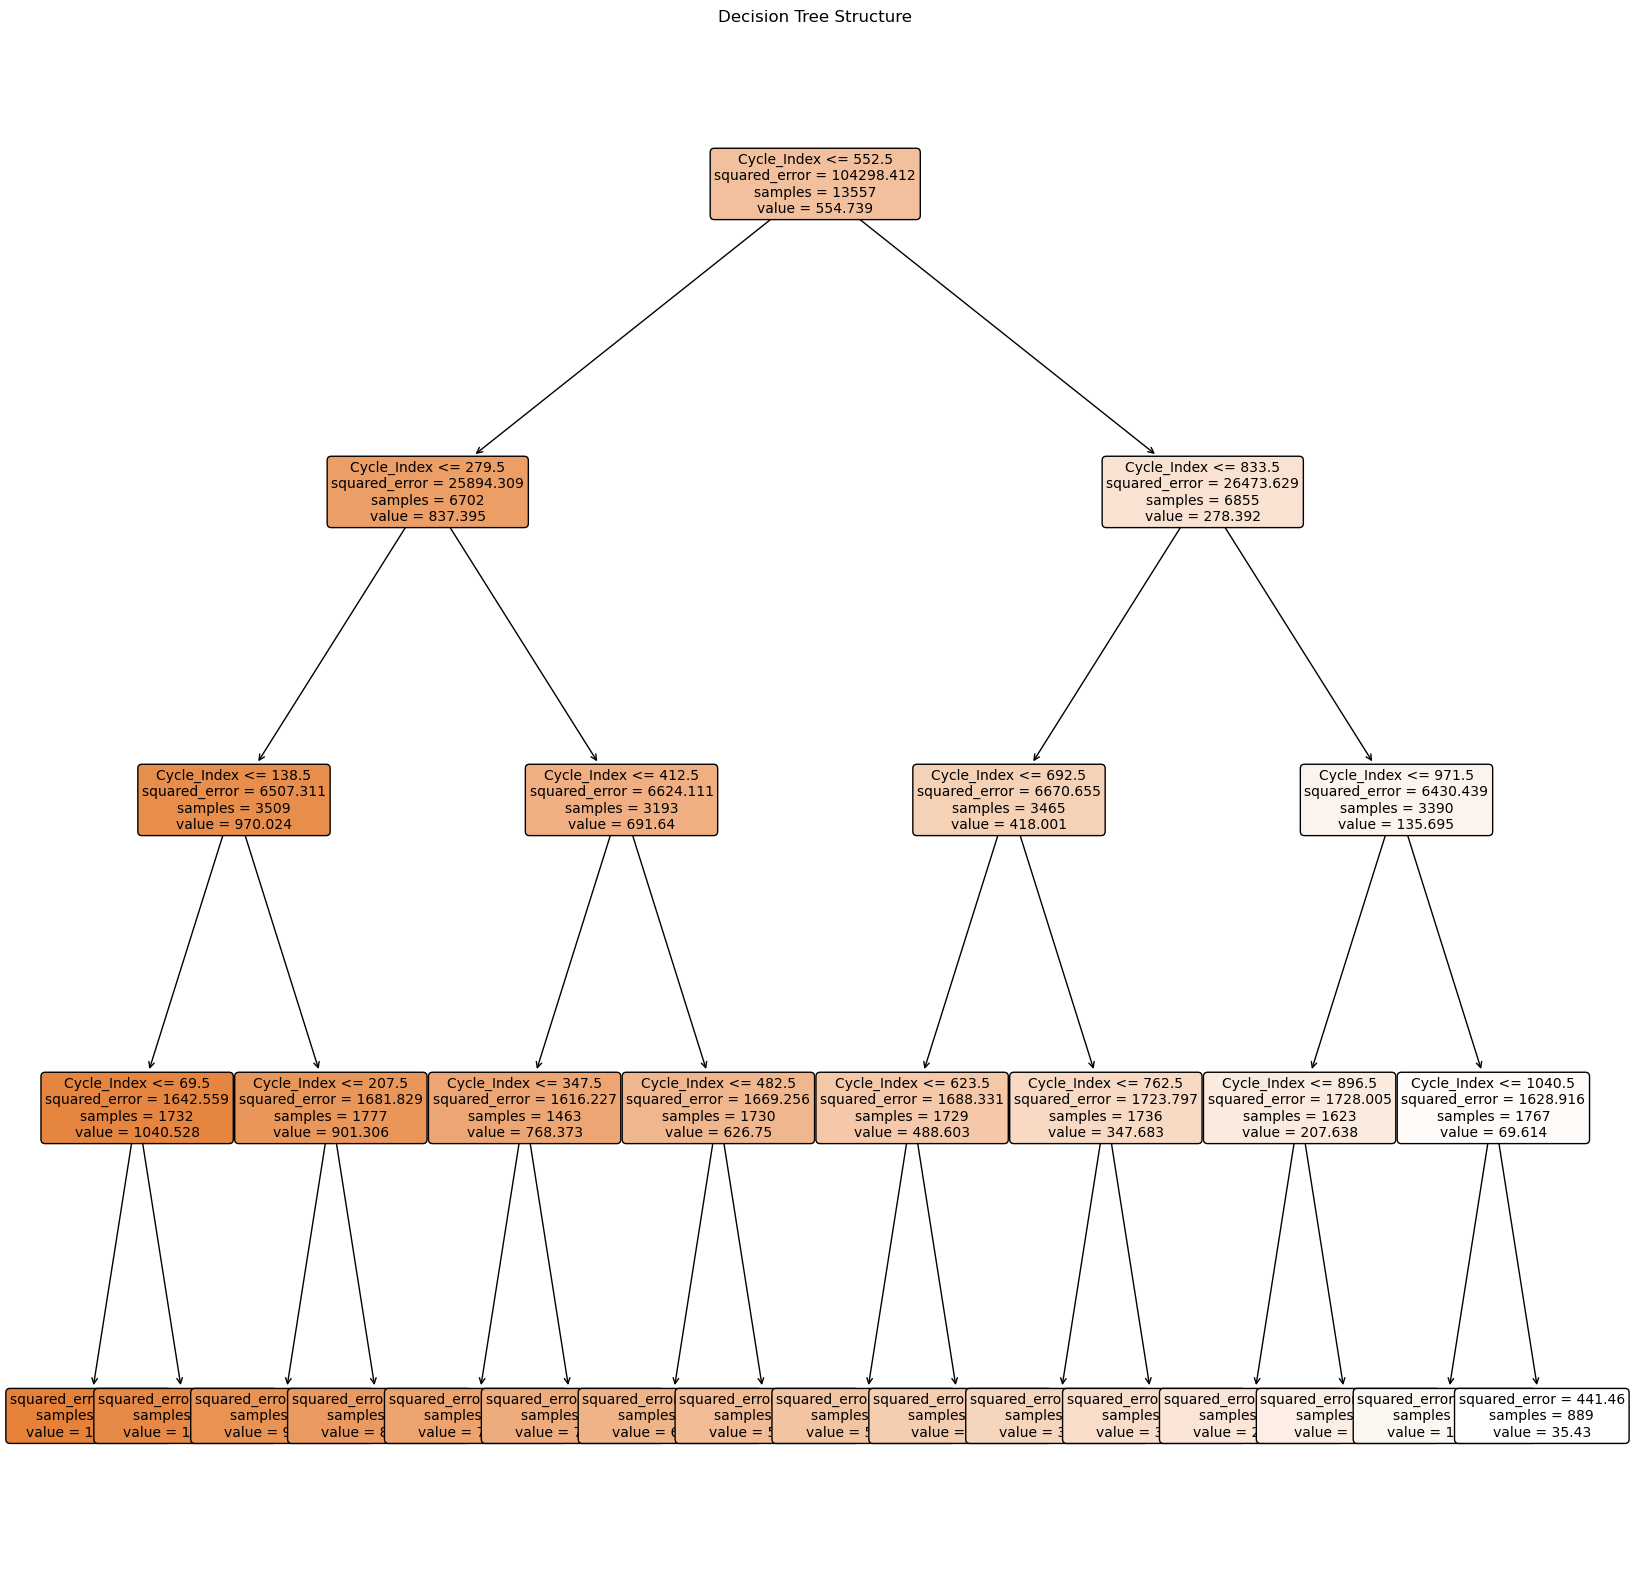

In [35]:
from sklearn.tree import plot_tree

# Visualizing decision tree
plt.figure(figsize=(20, 20))
plot_tree(
    regressor,
    feature_names=["Cycle_Index","Discharge Time (s)","Decrement 3.6-3.4V (s)","Max. Voltage Dischar. (V)","Min. Voltage Charg. (V)","Time at 4.15V (s)","Time constant current (s)","Charging time (s)"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure")
plt.show()

# RANDOM FOREST

In [22]:
from sklearn.ensemble import RandomForestRegressor

# Our forest consists of 100 trees with a max depth of 5 in this example
Random_forest = RandomForestRegressor(n_estimators=100, max_depth=5)
Random_forest.fit(RUL_Dataset_features_array,RUL_Dataset_label)

RandomForestRegressor(max_depth=5)

In [23]:
# Get predictions
y_pred = Random_forest.predict(RUL_Dataset_features_test)

mse = mean_squared_error(RUL_Dataset_label_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 95.0775


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [24]:
from sklearn.tree import export_graphviz
import pydot
from sklearn.tree import plot_tree

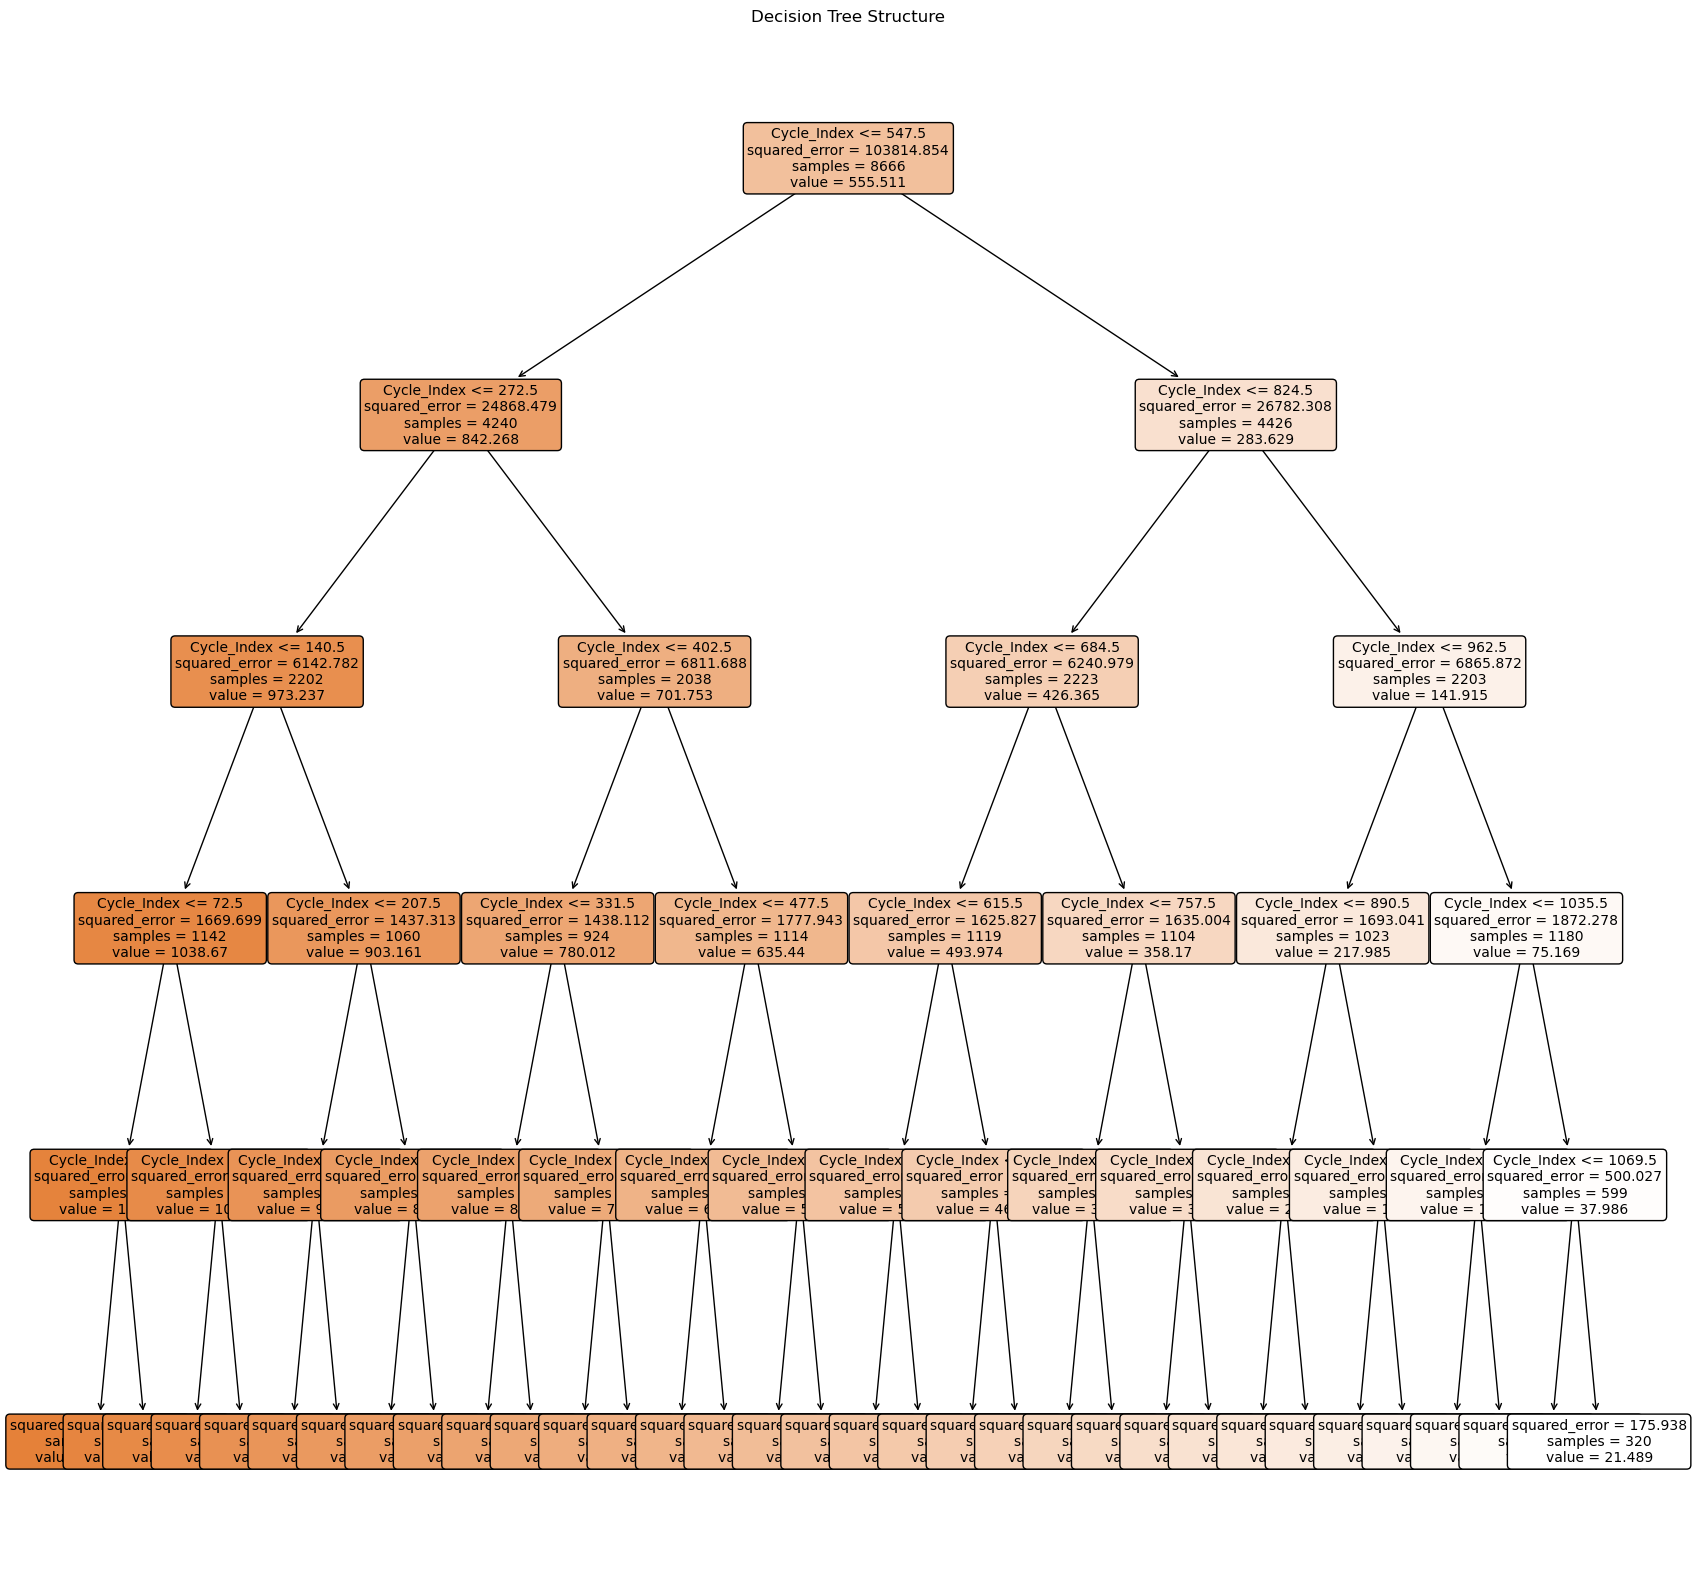

In [25]:
# Visualizing decision tree
plt.figure(figsize=(20, 20))
individual_tree = Random_forest.estimators_[99] 
plot_tree(
    individual_tree,
    feature_names=["Cycle_Index","Discharge Time (s)","Decrement 3.6-3.4V (s)","Max. Voltage Dischar. (V)","Min. Voltage Charg. (V)","Time at 4.15V (s)","Time constant current (s)","Charging time (s)"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure")
plt.show()